K-Means Clustering on Red Wine Quality Dataset - 5/31/26 - halarc1407

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "halarc1407"
# Load the Wine Quality dataset
data = pd.read_csv('winequality-red.csv')
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1.2: Load the Dataset

Date: 2026-05-31

Student ID: halarc1407

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Concise summary
print(data.info())
# Descriptive statistics
display(data.describe())

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-05-31

Student ID: halarc1407

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
display(Markdown("### Step 1.4: Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Check missing values
print(f"Missing values: {data.isnull().sum().sum()}")
# Fill any missing numerical values with the median
for column in data.select_dtypes(include=[np.number]).columns:
    data[column] = data[column].fillna(data[column].median())
# Remove duplicates
print(f"Duplicate rows before: {data.duplicated().sum()}")
data = data.drop_duplicates()
print(f"Duplicate rows after: {data.duplicated().sum()}")
print(f"Final shape: {data.shape}")
# Standardize numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print("\nFeatures standardized.")

### Step 1.4: Preprocess the Data

Date: 2026-05-31

Student ID: halarc1407

Missing values: 0
Duplicate rows before: 240
Duplicate rows after: 0
Final shape: (1359, 12)

Features standardized.


### Step 2: Hierarchical Clustering - Dendrogram

Date: 2026-05-31

Student ID: halarc1407

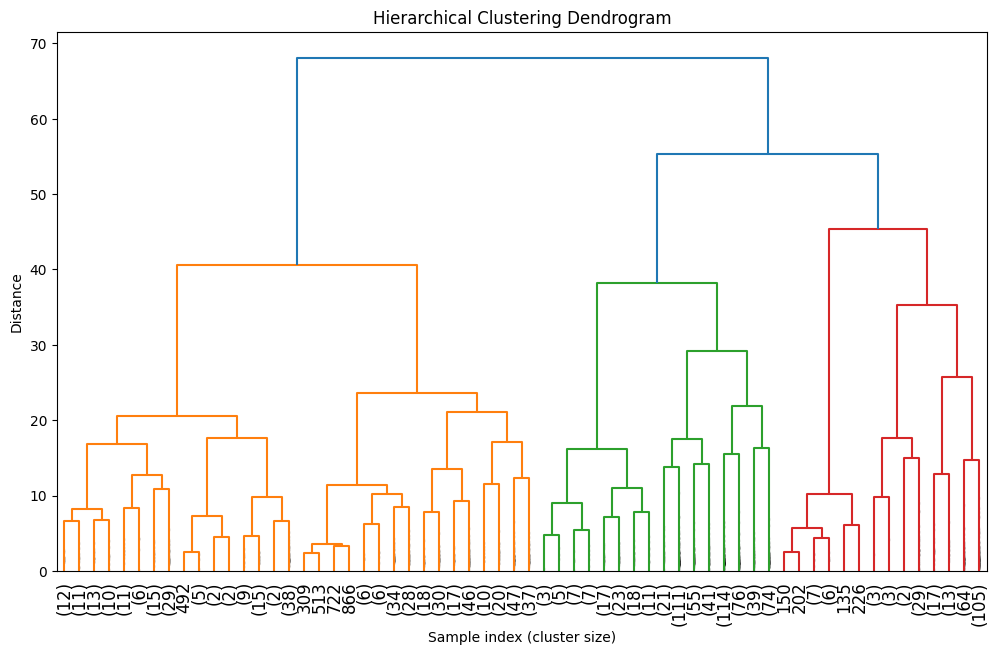

In [4]:
display(Markdown("### Step 2: Hierarchical Clustering - Dendrogram"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Hierarchical clustering to determine starting k
Z = linkage(scaled_data, method='ward')
# Plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index (cluster size)')
plt.ylabel('Distance')
plt.show()

In [5]:
display(Markdown("### Step 3: Initial K-Means Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Fit K-Means with initial k=3 from the dendrogram
initial_k = 3
kmeans = KMeans(n_clusters=initial_k, n_init=10, random_state=42)
kmeans.fit(scaled_data)
initial_labels = kmeans.labels_
print(f"Initial K-Means fit with k={initial_k}")
print(f"Cluster sizes:")
print(pd.Series(initial_labels).value_counts().sort_index())
print(f"\nInitial Silhouette Score: {silhouette_score(scaled_data, initial_labels):.4f}")

### Step 3: Initial K-Means Clustering

Date: 2026-05-31

Student ID: halarc1407

Initial K-Means fit with k=3
Cluster sizes:
0    329
1    433
2    597
Name: count, dtype: int64

Initial Silhouette Score: 0.1726


### Step 4: Optimize K with Elbow Method and Silhouette Score

Date: 2026-05-31

Student ID: halarc1407

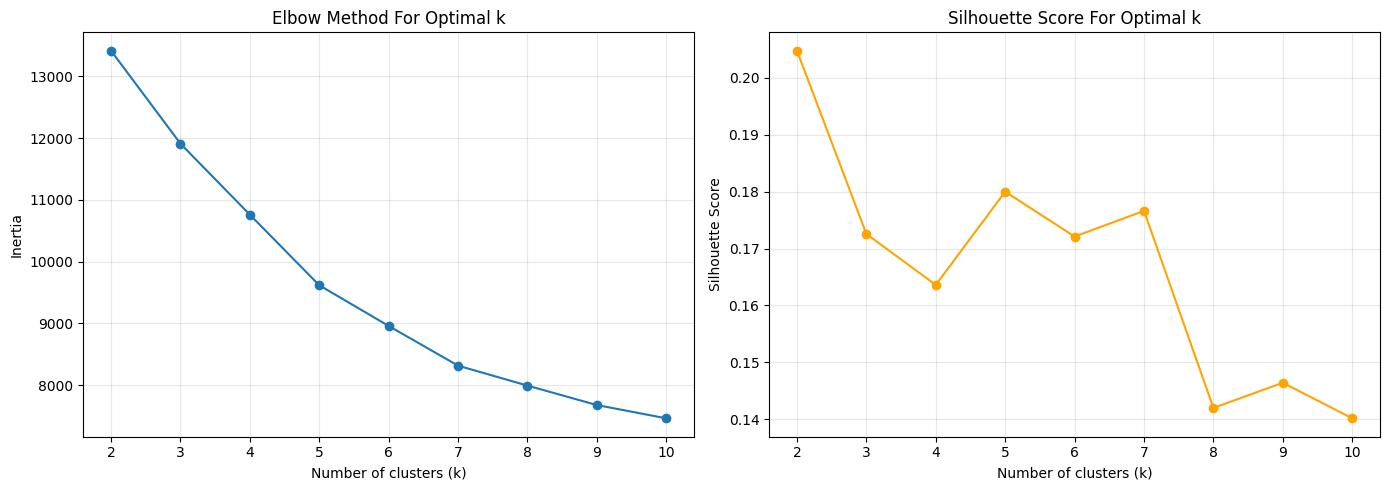

Silhouette scores by K:
  k=2: 0.2048
  k=3: 0.1726
  k=4: 0.1636
  k=5: 0.1800
  k=6: 0.1721
  k=7: 0.1766
  k=8: 0.1420
  k=9: 0.1464
  k=10: 0.1402


In [6]:
display(Markdown("### Step 4: Optimize K with Elbow Method and Silhouette Score"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Calculate inertia and silhouette scores for k=2..10
inertia = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_data, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score For Optimal k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Silhouette scores by K:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

In [7]:
display(Markdown("### Step 5: Evaluate the Optimized K-Means Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Refit with the optimal k (chosen based on silhouette score peak)
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
final_labels = kmeans_final.fit_predict(scaled_data)
print(f"Refit K-Means with optimal k={optimal_k}")
print(f"Cluster sizes:")
print(pd.Series(final_labels).value_counts().sort_index())
final_sil = silhouette_score(scaled_data, final_labels)
print(f"\nFinal Silhouette Score: {final_sil:.4f}")

### Step 5: Evaluate the Optimized K-Means Model

Date: 2026-05-31

Student ID: halarc1407

Refit K-Means with optimal k=2
Cluster sizes:
0    513
1    846
Name: count, dtype: int64

Final Silhouette Score: 0.2048


### Step 6: Visualize Clustering Results (PCA Projection)

Date: 2026-05-31

Student ID: halarc1407

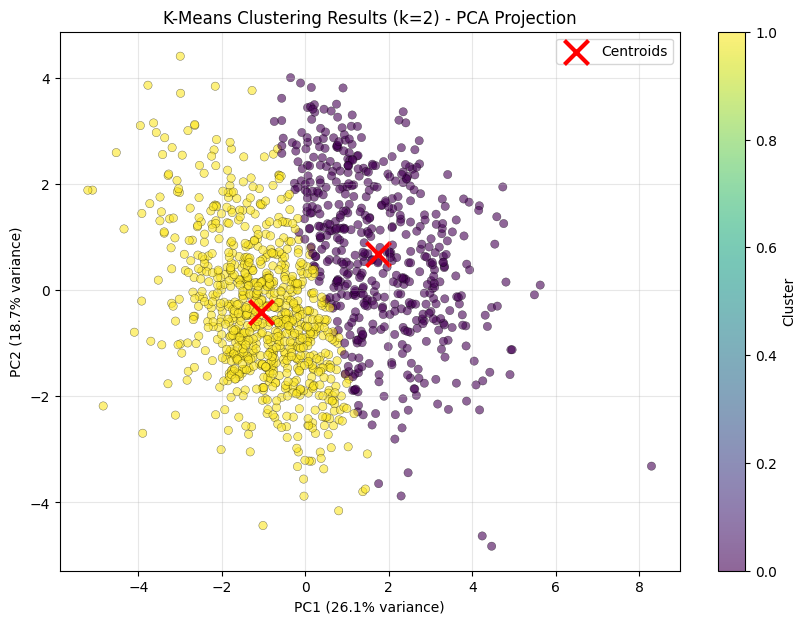

In [8]:
display(Markdown("### Step 6: Visualize Clustering Results (PCA Projection)"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Project to 2D using PCA for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=final_labels,
                       cmap='viridis', alpha=0.6, edgecolors='k', linewidths=0.3)
# Plot the centroids (transformed into PCA space)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='x', linewidths=3, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clustering Results (k={optimal_k}) - PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()